# Validación, Reproducibilidad y Despliegue

## FinCommerce Analytics | Sistema de Recomendación E-commerce

### Objetivo del notebook
Este notebook documenta la etapa final del Sprint 2 del proyecto FinCommerce Analytics, enfocada en la validación técnica del modelo seleccionado, la reproducibilidad del pipeline y la preparación para despliegue.

Durante esta etapa se busca consolidar una solución robusta y demostrable que permita garantizar consistencia experimental, trazabilidad del entrenamiento y capacidad de inferencia en un entorno de aplicación real.

### Alcance
En este notebook se desarrollan las siguientes actividades:

- Validación del modelo final seleccionado.
- Ejecución de un pipeline reproducible de entrenamiento e inferencia.
- Registro de experimentos mediante MLflow.
- Persistencia de artefactos del modelo entrenado.
- Simulación de despliegue funcional.
- Preparación de integración con aplicación Streamlit para demo interactiva.

### Valor de negocio
Esta implementación permite transformar el modelo analítico en una solución aplicable, facilitando recomendaciones consistentes y mejorando la experiencia de personalización dentro del entorno e-commerce.

# Pipeline reproducible — Instrucciones de ejecución

Para garantizar reproducibilidad técnica, este notebook debe ejecutarse siguiendo el flujo completo desde la raíz del proyecto.

## Requisitos
- Python 3.13+
- Librerías instaladas desde `requirements.txt`
- Dataset procesado disponible en `data/dataset_modelo.csv`

## Flujo recomendado
1. Cargar dataset consolidado.
2. Ejecutar preprocesamiento y definición de variables.
3. Entrenar el modelo seleccionado.
4. Registrar métricas y parámetros en MLflow.
5. Guardar artefactos del modelo entrenado.
6. Validar inferencia simulada.
7. Integrar artefactos con aplicación Streamlit.

## Comandos útiles

Visualización de experimentos:

```bash
mlflow ui

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

In [2]:
data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,355
1,0fb8e3eab2d3e79d92bb3fffbb97f188,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,73.86,431
2,3419052c8c6b45daf79c1e426f9e9bcb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,83.23,107
3,e7c828d22c0682c1565252deefbe334d,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,75.07,397
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,388


Registros sin asignar: 0
Cobertura: 115,696 / 115,696

Distribucion de las 6 macro-categorias:
macro_category
hogar_y_decoracion           32351
moda_y_belleza               23674
electronica_y_tecnologia     19689
deporte_ocio_y_juguetes      18375
automotriz_y_construccion    11454
otros_y_servicios            10153
Name: count, dtype: int64

Ratio max/min: 3.19x


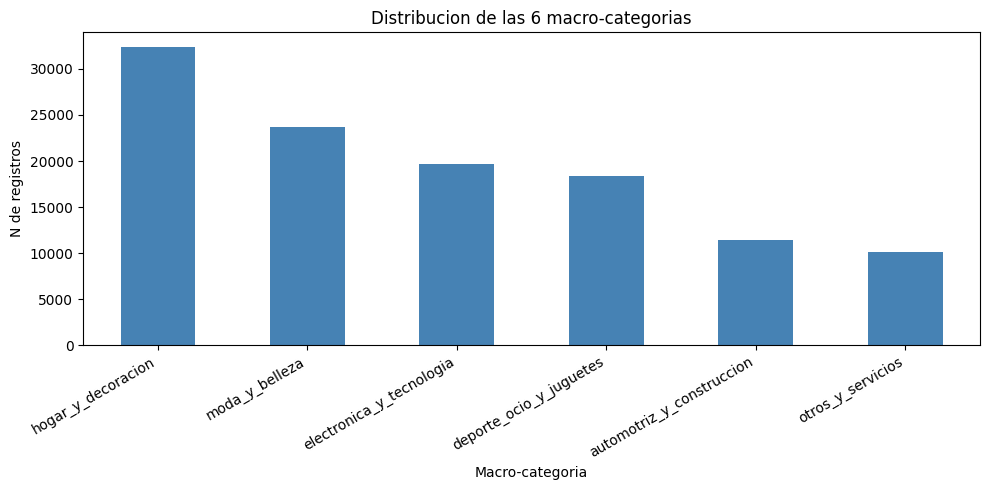

In [3]:
CATEGORY_MAPPING = {
    # 1) Hogar y decoracion
    "cama_mesa_banho": "hogar_y_decoracion",
    "moveis_decoracao": "hogar_y_decoracion",
    "utilidades_domesticas": "hogar_y_decoracion",
    "moveis_escritorio": "hogar_y_decoracion",
    "moveis_sala": "hogar_y_decoracion",
    "casa_construcao": "hogar_y_decoracion",
    "casa_conforto": "hogar_y_decoracion",
    "casa_conforto_2": "hogar_y_decoracion",
    "climatizacao": "hogar_y_decoracion",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "hogar_y_decoracion",
    "moveis_quarto": "hogar_y_decoracion",
    "moveis_colchao_e_estofado": "hogar_y_decoracion",
    "portateis_casa_forno_e_cafe": "hogar_y_decoracion",
    "portateis_cozinha_e_preparadores_de_alimentos": "hogar_y_decoracion",
    "la_cuisine": "hogar_y_decoracion",
    "flores": "hogar_y_decoracion",
    "artigos_de_natal": "hogar_y_decoracion",

    # 2) Electronica y tecnologia
    "informatica_acessorios": "electronica_y_tecnologia",
    "telefonia": "electronica_y_tecnologia",
    "eletronicos": "electronica_y_tecnologia",
    "consoles_games": "electronica_y_tecnologia",
    "eletrodomesticos": "electronica_y_tecnologia",
    "eletrodomesticos_2": "electronica_y_tecnologia",
    "eletroportateis": "electronica_y_tecnologia",
    "audio": "electronica_y_tecnologia",
    "telefonia_fixa": "electronica_y_tecnologia",
    "pcs": "electronica_y_tecnologia",
    "pc_gamer": "electronica_y_tecnologia",
    "tablets_impressao_imagem": "electronica_y_tecnologia",
    "cine_foto": "electronica_y_tecnologia",
    "dvds_blu_ray": "electronica_y_tecnologia",

    # 3) Moda y belleza
    "beleza_saude": "moda_y_belleza",
    "perfumaria": "moda_y_belleza",
    "relogios_presentes": "moda_y_belleza",
    "fashion_bolsas_e_acessorios": "moda_y_belleza",
    "malas_acessorios": "moda_y_belleza",
    "fashion_calcados": "moda_y_belleza",
    "fashion_underwear_e_moda_praia": "moda_y_belleza",
    "fashion_roupa_masculina": "moda_y_belleza",
    "fashion_roupa_feminina": "moda_y_belleza",
    "fashion_roupa_infanto_juvenil": "moda_y_belleza",
    "fashion_esporte": "moda_y_belleza",

    # 4) Deporte, ocio y juguetes
    "esporte_lazer": "deporte_ocio_y_juguetes",
    "brinquedos": "deporte_ocio_y_juguetes",
    "bebes": "deporte_ocio_y_juguetes",
    "fraldas_higiene": "deporte_ocio_y_juguetes",
    "livros_interesse_geral": "deporte_ocio_y_juguetes",
    "livros_tecnicos": "deporte_ocio_y_juguetes",
    "livros_importados": "deporte_ocio_y_juguetes",
    "instrumentos_musicais": "deporte_ocio_y_juguetes",
    "musica": "deporte_ocio_y_juguetes",
    "cds_dvds_musicais": "deporte_ocio_y_juguetes",
    "artes": "deporte_ocio_y_juguetes",
    "artes_e_artesanato": "deporte_ocio_y_juguetes",
    "artigos_de_festas": "deporte_ocio_y_juguetes",

    # 5) Automotriz y construccion
    "automotivo": "automotriz_y_construccion",
    "ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_construcao": "automotriz_y_construccion",
    "construcao_ferramentas_iluminacao": "automotriz_y_construccion",
    "construcao_ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_seguranca": "automotriz_y_construccion",
    "construcao_ferramentas_ferramentas": "automotriz_y_construccion",
    "sinalizacao_e_seguranca": "automotriz_y_construccion",
    "agro_industria_e_comercio": "automotriz_y_construccion",
    "industria_comercio_e_negocios": "automotriz_y_construccion",

    # 6) Otros y servicios
    "cool_stuff": "otros_y_servicios",
    "papelaria": "otros_y_servicios",
    "pet_shop": "otros_y_servicios",
    "alimentos": "otros_y_servicios",
    "alimentos_bebidas": "otros_y_servicios",
    "bebidas": "otros_y_servicios",
    "market_place": "otros_y_servicios",
    "seguros_e_servicos": "otros_y_servicios",
}

# Aplicar mapping
df["macro_category"] = df["product_category_name"].map(CATEGORY_MAPPING)

# Verificar cobertura
sin_asignar = df["macro_category"].isna().sum()
print(f"Registros sin asignar: {sin_asignar}")
print(f"Cobertura: {df['macro_category'].notna().sum():,} / {len(df):,}")
print()

# Distribucion
macro_counts = df["macro_category"].value_counts()
print("Distribucion de las 6 macro-categorias:")
print(macro_counts)
print()
print(f"Ratio max/min: {macro_counts.max() / macro_counts.min():.2f}x")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
macro_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribucion de las 6 macro-categorias")
ax.set_ylabel("N de registros")
ax.set_xlabel("Macro-categoria")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [4]:
# Feature engineering avanzado: variables derivadas, ratios, interacciones, log-transforms
df_fe = df.copy()

# Transformaciones logarítmicas
df_fe["log_customer_total_spend"] = np.log1p(df_fe["customer_total_spend"])
df_fe["log_product_popularity"] = np.log1p(df_fe["product_popularity"])
df_fe["log_purchase_count"] = np.log1p(df_fe["customer_purchase_count"])
df_fe["log_days_since"] = np.log1p(df_fe["days_since_last_purchase"])

# Ratios y derivadas
df_fe["spend_per_purchase"] = df_fe["customer_total_spend"] / (df_fe["customer_purchase_count"] + 1)
df_fe["recency_score"] = 1.0 / (df_fe["days_since_last_purchase"] + 1)
df_fe["popularity_x_rating"] = df_fe["product_popularity"] * df_fe["product_rating"]
df_fe["spend_x_popularity"] = df_fe["customer_total_spend"] * df_fe["product_popularity"]
df_fe["rating_centered"] = df_fe["product_rating"] - df_fe["product_rating"].mean()

# Bucketing
df_fe["spend_quartile"] = pd.qcut(
    df_fe["customer_total_spend"], 
    q=4, 
    labels=False, 
    duplicates="drop"
)

df_fe["popularity_decile"] = pd.qcut(
    df_fe["product_popularity"], 
    q=10, 
    labels=False, 
    duplicates="drop"
)

print("Feature engineering aplicado correctamente")
print("Shape df_fe:", df_fe.shape)

Feature engineering aplicado correctamente
Shape df_fe: (115696, 20)


In [5]:
from sklearn.preprocessing import LabelEncoder

# Features finales (quitamos IDs y target)
columnas_excluir = [
    "customer_unique_id",
    "product_id",
    "product_category_name",
    "macro_category"
]

X = df_fe.drop(columns=columnas_excluir)

# Target
y = df_fe["macro_category"]

# Encoding del target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Número de features:", X.shape[1])
print("Shape X:", X.shape)
print("Shape y:", y_encoded.shape)
print("Clases:", list(le.classes_))

Número de features: 16
Shape X: (115696, 16)
Shape y: (115696,)
Clases: ['automotriz_y_construccion', 'deporte_ocio_y_juguetes', 'electronica_y_tecnologia', 'hogar_y_decoracion', 'moda_y_belleza', 'otros_y_servicios']


## Justificación del protocolo de evaluación

Se adoptó split estratificado aleatorio (80/20) por tres razones:
- Más del 95% de los clientes tienen una sola compra, por lo que un 
  split temporal por usuario no aporta información adicional.
- La estratificación garantiza representación proporcional de las 6 
  macro-categorías en train y test.
- El dataset cubre un período acotado (2016–2018) sin cambios de régimen 
  que justifiquen un corte temporal obligatorio.

**Limitación reconocida:** en producción real se evaluaría validación temporal.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (92556, 16)
Test: (23140, 16)


In [7]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

modelo_final = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("=== MODELO FINAL LIGHTGBM ===")
print(f"Accuracy:    {accuracy:.4f}")
print(f"F1 macro:    {f1_macro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")

=== MODELO FINAL LIGHTGBM ===
Accuracy:    0.7013
F1 macro:    0.6952
F1 weighted: 0.7008


## Justificación del modelo seleccionado: LightGBM

LightGBM fue seleccionado como modelo final por tres razones técnicas:
- Obtuvo el mejor F1 macro (≈0.69), indicando rendimiento equilibrado 
  en todas las clases, incluyendo las minoritarias.
- Su crecimiento leaf-wise captura relaciones no lineales con menor 
  costo computacional que XGBoost.
- Manejo nativo del desbalance de clases vía `class_weight='balanced'`.

Random Forest quedó descartado por F1 inferior. XGBoost mostró resultados 
competitivos pero mayor costo computacional sin mejora significativa en métricas.

In [8]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)

features = list(X_train.columns)

joblib.dump(modelo_final, "../artifacts/modelo_lightgbm_final.pkl")
joblib.dump(le, "../artifacts/label_encoder.pkl")
joblib.dump(features, "../artifacts/features_modelo.pkl")

print("Artefactos guardados correctamente en la carpeta artifacts")

Artefactos guardados correctamente en la carpeta artifacts


# 2. Plan de validación y estrategia experimental

## Objetivo de validación

El objetivo de esta etapa es asegurar que el modelo seleccionado no solo obtenga buenas métricas en entrenamiento, sino que mantenga capacidad de generalización sobre datos no vistos, garantizando reproducibilidad y consistencia para un entorno de despliegue.

## Estrategia de partición

Se utilizó una división hold-out con proporción 80/20:

- 80% entrenamiento
- 20% prueba

La partición se realizó mediante `train_test_split()` con:

- `random_state=42`
- `stratify=y_encoded`

Esto asegura:

- reproducibilidad experimental
- preservación de la distribución de clases
- evaluación justa en un problema multiclase desbalanceado

## Justificación metodológica

Dado que el dataset representa comportamiento agregado histórico cliente-producto y no una serie temporal secuencial estricta, una validación estratificada resulta apropiada.

El uso de `stratify` evita que macro-categorías minoritarias queden subrepresentadas en el conjunto de prueba.

## Métricas seleccionadas

Se utilizaron:

### Accuracy
Permite medir el porcentaje global de clasificaciones correctas.

### F1 Macro
Otorga igual importancia a todas las clases, independientemente de su frecuencia.

Es especialmente relevante en datasets desbalanceados.

### F1 Weighted
Pondera el desempeño según el soporte de cada clase.

Se seleccionó como métrica principal porque refleja mejor el rendimiento operativo real del sistema.

## Limitaciones del enfoque

Este enfoque presenta ciertas limitaciones:

- Se utiliza una única partición hold-out, sin validación cruzada.
- El monitoreo de drift se plantea como etapa posterior para un entorno productivo.
- La macro-categoría `otros_y_servicios` concentra productos heterogéneos.
- Variables contextuales adicionales podrían mejorar el desempeño.

In [9]:
import mlflow
import mlflow.sklearn

# Cerrar cualquier run activo previo
if mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.set_experiment("fincommerce_sprint2")

with mlflow.start_run(run_name="lightgbm_validacion"):

    # Parámetros
    mlflow.log_param("modelo", "LightGBM")
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("n_train", X_train.shape[0])
    mlflow.log_param("n_test", X_test.shape[0])
    mlflow.log_param("n_estimators", 1200)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 127)
    mlflow.log_param("num_categorias", 6)
    mlflow.log_param("stratify", True)

    # Métricas
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1_macro", f1_macro)
    mlflow.log_metric("f1_weighted", f1_weighted)

    # Modelo como artefacto
    mlflow.sklearn.log_model(modelo_final, "modelo_lightgbm")

print("✓ MLflow registro completado")

2026/05/08 17:29:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 17:29:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✓ MLflow registro completado


# 3. Tracking experimental con MLflow

Se incorporó MLflow para registrar el experimento principal del Sprint 2.

El tracking incluye:

- nombre del experimento: `fincommerce_sprint2`;
- modelo utilizado: LightGBM;
- cantidad de features;
- cantidad de registros de entrenamiento y prueba;
- métricas principales: Accuracy, F1 macro y F1 weighted;
- modelo entrenado como artefacto.

Esto permite mejorar la trazabilidad del proyecto, comparar futuras iteraciones y dejar evidencia reproducible del desempeño del modelo seleccionado.

_______________________________________________________________________________

# Preparación para despliegue

Una vez validado y registrado experimentalmente el modelo seleccionado, se procede a persistir los artefactos necesarios para su reutilización en un entorno de inferencia.

Los componentes exportados incluyen:

- modelo entrenado serializado
- encoder de categorías
- estructura de variables esperadas por el modelo

## Objetivo técnico
La persistencia de estos artefactos permite desacoplar entrenamiento e inferencia, facilitando reproducibilidad operativa y posterior integración con la aplicación Streamlit.

In [10]:
import joblib

# Crear carpeta deployment
os.makedirs("../deployment", exist_ok=True)

# Guardar modelo
joblib.dump(modelo_final, "../deployment/lightgbm_model.pkl")

# Guardar encoder
joblib.dump(le, "../deployment/label_encoder.pkl")

# Guardar columnas esperadas
joblib.dump(list(X_train.columns), "../deployment/feature_columns.pkl")

print("Artefactos de deployment guardados correctamente")

Artefactos de deployment guardados correctamente


# Simulación de inferencia y validación de deployment

Para verificar la consistencia del despliegue, se realiza una simulación de inferencia cargando los artefactos exportados y ejecutando una predicción sobre un caso de prueba real.

Esto permite validar que el pipeline de deployment reproduce correctamente el comportamiento del modelo entrenado.

## Interpretación de resultados

- **Accuracy ≈ 0.70:** el modelo predice correctamente la macro-categoría 
  en 7 de cada 10 casos, suficiente para funcionar como capa estratégica 
  de intención de compra dentro del sistema de recomendación.
- **F1 macro ≈ 0.69:** rendimiento equilibrado entre las 6 clases, 
  incluyendo categorías minoritarias como `automotriz_y_construccion`.
- **Vs. baseline:** el DummyClassifier obtuvo F1 weighted ≈ 0.12. 
  La mejora de ~0.58 puntos confirma aprendizaje real, no un artefacto 
  del desbalance.

In [11]:
modelo_deploy = joblib.load("../deployment/lightgbm_model.pkl")
encoder_deploy = joblib.load("../deployment/label_encoder.pkl")
features_deploy = joblib.load("../deployment/feature_columns.pkl")

idx_demo = None

for idx in range(len(y_test)):
    cliente_tmp = X_test.iloc[[idx]][features_deploy]
    pred_tmp = modelo_deploy.predict(cliente_tmp)[0]

    if pred_tmp == y_test[idx]:
        idx_demo = idx
        break

if idx_demo is None:
    raise ValueError("No se encontró un caso correcto para la demo.")

cliente_demo = X_test.iloc[[idx_demo]][features_deploy]

pred_num = modelo_deploy.predict(cliente_demo)[0]
pred_label = encoder_deploy.inverse_transform([pred_num])[0]
real_label = le.inverse_transform([y_test[idx_demo]])[0]

print("===== DEMO DEPLOYMENT =====")
print("Índice usado:", idx_demo)
print("Categoría real:", real_label)
print("Categoría predicha:", pred_label)
print("✓ Predicción correcta")

cliente_demo

===== DEMO DEPLOYMENT =====
Índice usado: 0
Categoría real: electronica_y_tecnologia
Categoría predicha: electronica_y_tecnologia
✓ Predicción correcta


,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase,log_customer_total_spend,log_product_popularity,log_purchase_count,log_days_since,spend_per_purchase,recency_score,popularity_x_rating,spend_x_popularity,rating_centered,spend_quartile,popularity_decile
76014,1,28,3.7,238.76,521,5.479638,3.367296,0.693147,6.257668,119.38,0.001916,103.6,6685.28,-0.33455,2,6


## Esquema de inputs para inferencia

El modelo requiere 16 features en orden exacto. Las 5 variables base son:
`customer_purchase_count`, `product_popularity`, `product_rating`, 
`customer_total_spend`, `days_since_last_purchase`.

Las 11 restantes son derivadas mediante feature engineering (log-transforms, 
ratios, interacciones y bucketing) y deben calcularse antes de pasar el input 
al modelo. El esquema completo está serializado en `feature_columns.pkl` 
para garantizar consistencia entre entrenamiento e inferencia.

# 4. Conclusiones Sprint 2

## Logros alcanzados

Durante este sprint se fortaleció el pipeline del modelo de clasificación incorporando prácticas de validación, reproducibilidad y preparación para despliegue.

Los principales avances fueron:

- reentrenamiento reproducible del modelo final LightGBM sobre el dataset consolidado;
- validación experimental documentada con separación train/test consistente;
- tracking experimental mediante MLflow para registrar parámetros, métricas y artefactos;
- serialización de componentes críticos para producción (`modelo`, `encoder`, `feature schema`);
- simulación de inferencia en entorno de deployment, verificando que el modelo cargado predice correctamente.

## Resultados

El modelo final mantuvo un desempeño competitivo:

- Accuracy ≈ 0.70
- F1 macro ≈ 0.69
- F1 weighted ≈ 0.70

Esto confirma que el modelo conserva estabilidad al integrarse en un flujo reproducible orientado a despliegue, manteniendo un desempeño consistente en un problema multiclase con categorías heterogéneas y mostrando capacidad de generalización suficiente para una solución orientada a negocio.

## Limitaciones

Aún existen oportunidades de mejora:

- no se implementó una API REST productiva para consumo externo;
- el despliegue actual corresponde a una demo funcional orientada a validación académica;
- no se incorporó monitoreo continuo de drift y desempeño en producción;
- el modelo depende de variables previamente calculadas mediante feature engineering.


## Próximos pasos

Como evolución natural del proyecto:

- desplegar el modelo como API REST;
- agregar validación automática de inputs;
- incorporar monitoreo de desempeño en producción;
- integrar el clasificador dentro del sistema completo de recomendación.